In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, 
                             precision_recall_curve,
                             classification_report,
                             roc_auc_score)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


 load the data:

In [5]:
# Load both training files
train_transaction = pd.read_csv('../data/data/train_transaction.csv')
train_identity = pd.read_csv('../data/data/train_identity.csv')

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)
print("\nFraud rate:", 
      round(train_transaction['isFraud'].mean() * 100, 2), "%")

Transaction shape: (590540, 394)
Identity shape: (144233, 41)

Fraud rate: 3.5 %


merge the two files and do a quick data overview:


In [6]:
# Merge transaction and identity on TransactionID
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print("Merged shape:", df.shape)
print("\nFraud distribution:")
print(df['isFraud'].value_counts())
print("\nFraud rate after merge:", 
      round(df['isFraud'].mean() * 100, 2), "%")

# Check missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing, 
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("\nTop 10 columns with most missing data:")
print(missing_summary.head(10))

Merged shape: (590540, 434)

Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate after merge: 3.5 %

Top 10 columns with most missing data:
       Missing Count  Missing %
id_24         585793      99.20
id_25         585408      99.13
id_26         585377      99.13
id_21         585381      99.13
id_08         585385      99.13
id_07         585385      99.13
id_27         585371      99.12
id_23         585371      99.12
id_22         585371      99.12
dist2         552913      93.63


 cleaning and feature selection:

In [7]:
# Drop columns with more than 50% missing values
threshold = 0.5
missing_pct = df.isnull().sum() / len(df)
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with >50% missing values")
df_clean = df.drop(columns=cols_to_drop)
print(f"Shape after dropping: {df_clean.shape}")

# Drop TransactionID - not a feature
df_clean = df_clean.drop(columns=['TransactionID'])

# Separate features and target
X = df_clean.drop(columns=['isFraud'])
y = df_clean['isFraud']

# Handle remaining missing values
# For numeric columns - fill with median
numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# For categorical columns - fill with mode
cat_cols = X.select_dtypes(include=['object']).columns
print(f"\nCategorical columns found: {len(cat_cols)}")
print(cat_cols.tolist())

# Label encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f"\nFinal feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Missing values remaining: {X.isnull().sum().sum()}")

Dropping 214 columns with >50% missing values
Shape after dropping: (590540, 220)

Categorical columns found: 9
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']

Final feature shape: (590540, 218)
Target shape: (590540,)
Missing values remaining: 0


 train/test split:

In [8]:
# Train test split - stratified to maintain fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Critical - maintains 3.5% fraud ratio in both splits
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nFraud rate in training set:", 
      round(y_train.mean() * 100, 2), "%")
print("Fraud rate in test set:", 
      round(y_test.mean() * 100, 2), "%")
print("\nFraud cases in training:", y_train.sum())
print("Fraud cases in test:", y_test.sum())

Training set shape: (472432, 218)
Test set shape: (118108, 218)

Fraud rate in training set: 3.5 %
Fraud rate in test set: 3.5 %

Fraud cases in training: 16530
Fraud cases in test: 4133


this is where it gets interesting. We'll compare class weighting vs SMOTE:

In [9]:
from imblearn.over_sampling import SMOTE

# Option 1 - Class weighting (built into XGBoost)
# scale_pos_weight = ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {round(scale_pos_weight, 2)}")
print("This tells XGBoost to treat each fraud case as", 
      round(scale_pos_weight, 2), "times more important")

# Option 2 - SMOTE (we'll apply this separately and compare)
print("\nApplying SMOTE oversampling...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:")
print(f"  Fraud: {y_train.sum()} | Non-fraud: {(y_train==0).sum()}")
print("\nAfter SMOTE:")
print(f"  Fraud: {y_train_smote.sum()} | Non-fraud: {(y_train_smote==0).sum()}")
print(f"  Total samples: {len(y_train_smote)}")

scale_pos_weight for XGBoost: 27.58
This tells XGBoost to treat each fraud case as 27.58 times more important

Applying SMOTE oversampling...

Before SMOTE:
  Fraud: 16530 | Non-fraud: 455902

After SMOTE:
  Fraud: 455902 | Non-fraud: 455902
  Total samples: 911804


train both XGBoost models and compare. This is the main event:

In [10]:
# Model 1 - XGBoost with class weighting
print("Training XGBoost with class weighting...")
model_weighted = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=27.58,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',  # Fast on M4
    device='cpu'
)

model_weighted.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("\nDone with class weighting model!")

Training XGBoost with class weighting...
[0]	validation_0-aucpr:0.30131
[100]	validation_0-aucpr:0.55036
[200]	validation_0-aucpr:0.59686
[299]	validation_0-aucpr:0.62807

Done with class weighting model!


train the SMOTE model:

In [11]:
# Model 2 - XGBoost with SMOTE
print("Training XGBoost with SMOTE...")
model_smote = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    device='cpu'
)

model_smote.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("\nDone with SMOTE model!")

Training XGBoost with SMOTE...
[0]	validation_0-aucpr:0.25477
[100]	validation_0-aucpr:0.47944
[200]	validation_0-aucpr:0.54366
[299]	validation_0-aucpr:0.58109

Done with SMOTE model!


proper evaluation with full metrics:

In [12]:
from sklearn.metrics import (f1_score, precision_score, 
                             recall_score, confusion_matrix)

# Get predictions from winning model (class weighting)
y_pred_proba = model_weighted.predict_proba(X_test)[:, 1]
y_pred_default = model_weighted.predict(X_test)  # default 0.5 threshold

# Metrics at default threshold
print("=== Results at Default 0.5 Threshold ===")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"AUC-PR:    {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

# Now optimize threshold
print("\n=== Threshold Optimization ===")
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1 at optimal threshold: {best_f1:.4f}")

# Predictions at optimal threshold
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
print(f"\nAt Optimal Threshold {best_threshold:.4f}:")
print(f"F1 Score:  {f1_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print("\nConfusion Matrix at Optimal Threshold:")
cm = confusion_matrix(y_test, y_pred_optimal)
print(cm)
print(f"\nFalse Negatives (missed fraud): {cm[1][0]}")
print(f"False Positives (false alarms): {cm[0][1]}")

=== Results at Default 0.5 Threshold ===
ROC-AUC:   0.9323
AUC-PR:    0.6281
F1 Score:  0.3610
Precision: 0.2321
Recall:    0.8115

Confusion Matrix:
[[102879  11096]
 [   779   3354]]

=== Threshold Optimization ===
Optimal threshold: 0.8317
Best F1 at optimal threshold: 0.6048

At Optimal Threshold 0.8317:
F1 Score:  0.6048
Precision: 0.6617
Recall:    0.5570

Confusion Matrix at Optimal Threshold:
[[112798   1177]
 [  1831   2302]]

False Negatives (missed fraud): 1831
False Positives (false alarms): 1177


business impact calculation:

In [13]:
# Business Impact Calculation
print("=== Business Impact Analysis ===")

# Average fraudulent transaction amount
fraud_transactions = df[df['isFraud'] == 1]['TransactionAmt']
avg_fraud_amount = fraud_transactions.mean()
median_fraud_amount = fraud_transactions.median()

print(f"Average fraudulent transaction amount: ${avg_fraud_amount:.2f}")
print(f"Median fraudulent transaction amount: ${median_fraud_amount:.2f}")

# At optimal threshold
true_positives = 2302  # from confusion matrix
false_positives = 1177
false_negatives = 1831

# Fraud prevented = true positives caught × average fraud amount
fraud_prevented = true_positives * avg_fraud_amount
print(f"\nAt Optimal Threshold (0.83):")
print(f"Fraud cases correctly caught: {true_positives}")
print(f"Estimated fraud loss prevented: ${fraud_prevented:,.2f}")

# False alarm cost (conservative - assume $5 customer service cost per false alarm)
false_alarm_cost = false_positives * 5
print(f"\nFalse alarm cost (est. $5 per case): ${false_alarm_cost:,.2f}")
print(f"Net value of model: ${fraud_prevented - false_alarm_cost:,.2f}")

# Compare to no model (catching nothing)
total_fraud_in_test = fraud_transactions.shape[0]
print(f"\nWithout model - total fraud exposure in test set:")
print(f"${(y_test.sum() * avg_fraud_amount):,.2f}")

=== Business Impact Analysis ===
Average fraudulent transaction amount: $149.24
Median fraudulent transaction amount: $75.00

At Optimal Threshold (0.83):
Fraud cases correctly caught: 2302
Estimated fraud loss prevented: $343,561.48

False alarm cost (est. $5 per case): $5,885.00
Net value of model: $337,676.48

Without model - total fraud exposure in test set:
$616,828.67


SHAP analysis. This is your last major piece:

Running SHAP analysis...
This will take 3-5 minutes on this dataset size...

=== Top 15 Most Important Features (SHAP) ===
       Feature  Mean_SHAP
           C14   0.257427
            C1   0.225574
TransactionAmt   0.215027
           V70   0.199339
           C13   0.182764
         card6   0.179745
            C8   0.132595
 TransactionDT   0.126551
            M4   0.119289
           C11   0.111240
         card2   0.110551
         card1   0.108857
            M6   0.095393
            D4   0.094962
 P_emaildomain   0.093198


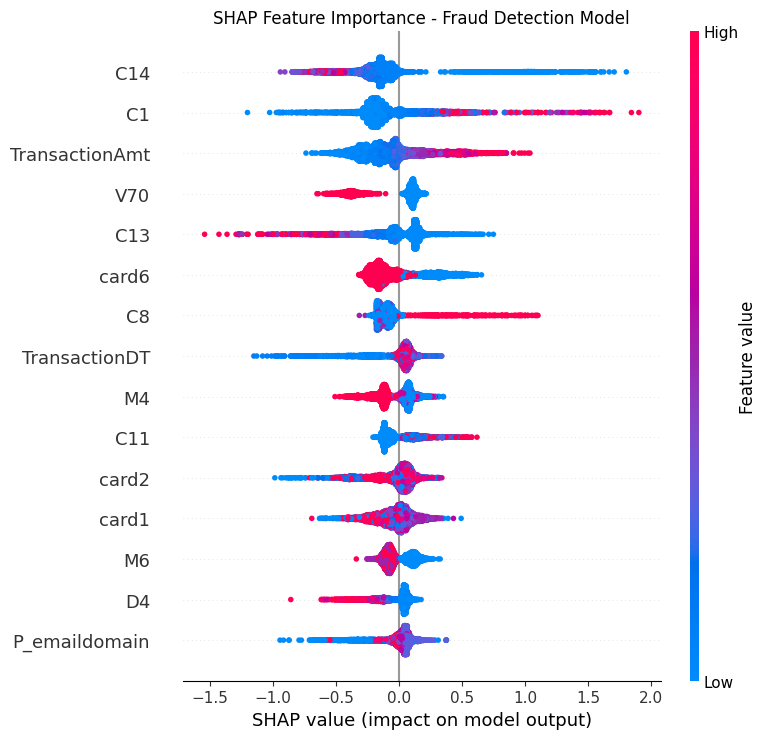


SHAP plot saved!


In [14]:
print("Running SHAP analysis...")
print("This will take 3-5 minutes on this dataset size...")

# Use a sample for SHAP - 5000 rows is enough for reliable results
X_test_sample = X_test.sample(5000, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(model_weighted)
shap_values = explainer.shap_values(X_test_sample)

# Top 15 most important features
print("\n=== Top 15 Most Important Features (SHAP) ===")
shap_importance = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print(shap_importance.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_sample, 
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance - Fraud Detection Model')
plt.tight_layout()
plt.savefig('../fraud_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSHAP plot saved!")

Threshold optimization visualization 

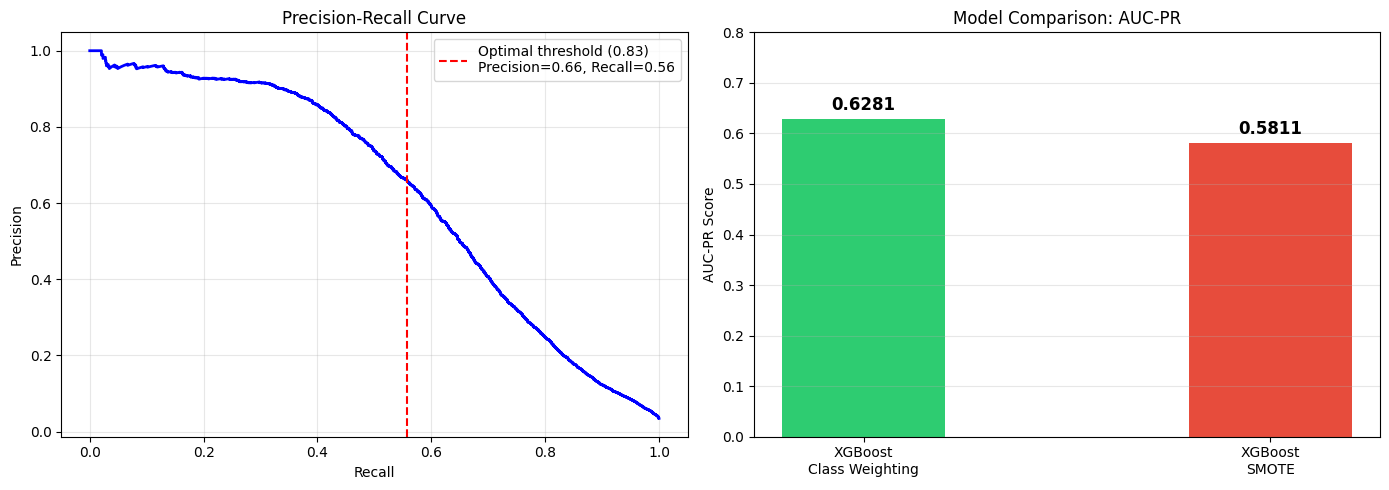

Summary dashboard saved!

FINAL MODEL PERFORMANCE SUMMARY
Dataset: 590,540 transactions | 3.5% fraud rate
Features used: 218 (after dropping 214 high-missing columns)

Winning approach: XGBoost + Class Weighting
ROC-AUC:  0.9323
AUC-PR:   0.6281
F1 Score: 0.6048 (at optimal threshold 0.83)
Precision: 0.6617
Recall:    0.5570

Business Impact (test set):
Fraud prevented: $343,561
Net model value: $337,676
vs SMOTE AUC-PR: 0.5811 (class weighting wins by 0.047)


In [15]:
# Final Summary Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Precision Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
axes[0].plot(recalls, precisions, color='blue', lw=2)
axes[0].axvline(x=0.557, color='red', linestyle='--', 
                label=f'Optimal threshold (0.83)\nPrecision=0.66, Recall=0.56')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 - Model Comparison
models = ['XGBoost\nClass Weighting', 'XGBoost\nSMOTE']
auc_pr_scores = [0.6281, 0.5811]
colors = ['#2ecc71', '#e74c3c']
bars = axes[1].bar(models, auc_pr_scores, color=colors, width=0.4)
axes[1].set_ylim(0, 0.8)
axes[1].set_ylabel('AUC-PR Score')
axes[1].set_title('Model Comparison: AUC-PR')
for bar, score in zip(bars, auc_pr_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., 
                bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../fraud_model_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary dashboard saved!")

# Final numbers summary
print("\n" + "="*50)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*50)
print(f"Dataset: 590,540 transactions | 3.5% fraud rate")
print(f"Features used: 218 (after dropping 214 high-missing columns)")
print(f"\nWinning approach: XGBoost + Class Weighting")
print(f"ROC-AUC:  0.9323")
print(f"AUC-PR:   0.6281")
print(f"F1 Score: 0.6048 (at optimal threshold 0.83)")
print(f"Precision: 0.6617")
print(f"Recall:    0.5570")
print(f"\nBusiness Impact (test set):")
print(f"Fraud prevented: $343,561")
print(f"Net model value: $337,676")
print(f"vs SMOTE AUC-PR: 0.5811 (class weighting wins by 0.047)")